# Exercício sobre datasets e análise dos resultados de treinamento

**Observação**: Verifiquem se o uso de GPU está habilitado.

## Importando as bibliotecas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Deixa os resultados reproduziveis
tf.keras.utils.set_random_seed(42)

## Baixando o conjunto de dados MNIST


O conjunto de dados MNIST de dígitos manuscritos, pode ser baixado com o [TF](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/mnist/load_data).

O conjunto contém imagens 28x28 pixels em tons de cinza dos 10 dígitos (0-9).
Ele possui um conjunto de treinamento com 60.000 imagens e um conjunto de teste com 10.000.

In [ ]:
(ltrain_images, ltrain_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

## Divindo em o conjunto inicial de treinamento em um conjunto de treinamento menor e um conjunto de validação

### Separamos as primeiras 10.000 imagens para o conjunto de validação.

In [ ]:
val_images = ltrain_images[:10000]
val_labels = ltrain_labels[:10000]

In [ ]:
print(val_images.shape)
print(val_labels.shape)

(10000, 28, 28)
(10000,)


### As 50.000 restantes vão para o novo conjunto de treinamento (menor)

In [ ]:
train_images = ltrain_images[10000:]
train_labels = ltrain_labels[10000:]

In [ ]:
print(train_images.shape)
print(train_labels.shape)

(50000, 28, 28)
(50000,)


## Pré-processamento dos dados

Vamos aplicar normalização aos dados (i.e., atributos) dos três conjuntos.

Como os valores dos pixels variam entre 0 e 255, basta dividí-los por 255.0 e o intervalo final ficará entre 0.0 e 1.0.

In [ ]:
train_images  = train_images / 255.0
val_images = val_images / 255.0
test_images = test_images / 255.0

## Execute a célula de código abaixo e analise as figuras geradas e os resultados de desempenho nos três conjuntos.


Epoch 1/30


1563/1563 [==============================] - 2s 1ms/step - loss: 1.4385 - accuracy: 0.5022 - val_loss: 1.3189 - val_accuracy: 0.5309
Epoch 2/30
1563/1563 [==============================] - 2s 980us/step - loss: 1.5153 - accuracy: 0.4629 - val_loss: 1.5891 - val_accuracy: 0.4050
Epoch 3/30
1563/1563 [==============================] - 2s 981us/step - loss: 1.6193 - accuracy: 0.4043 - val_loss: 1.5797 - val_accuracy: 0.4301
Epoch 4/30
1563/1563 [==============================] - 2s 985us/step - loss: 1.6716 - accuracy: 0.3940 - val_loss: 1.7377 - val_accuracy: 0.3836
Epoch 5/30
1563/1563 [==============================] - 2s 977us/step - loss: 1.6940 - accuracy: 0.3798 - val_loss: 1.7418 - val_accuracy: 0.3897
Epoch 6/30
1563/1563 [==============================] - 2s 1ms/step - loss: 1.7420 - accuracy: 0.3659 - val_loss: 1.8464 - val_accuracy: 0.3244
Epoch 7/30
1563/1563 [==============================] - 2s 997us/step - loss: 1.7409 - accuracy: 0.3667 - val_loss: 1.8552 - 

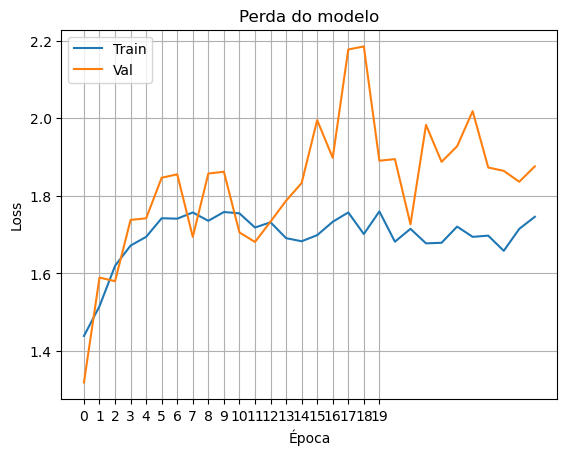

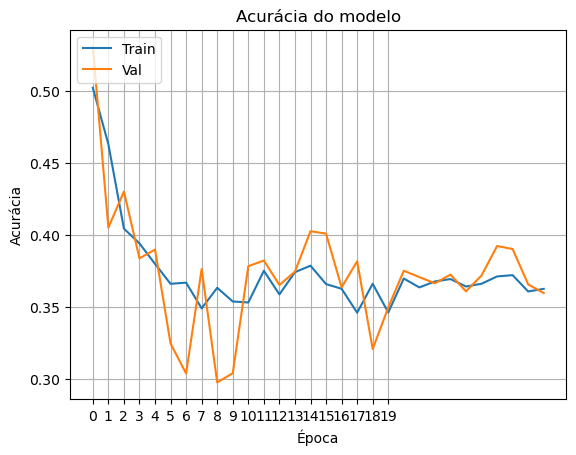

1563/1563 [==============================] - 1s 814us/step - loss: 1.6894 - accuracy: 0.3555
Treinamento: [1.6894019842147827, 0.3555000126361847]
313/313 [==============================] - 0s 799us/step - loss: 1.8758 - accuracy: 0.3595
Validação: [1.8757617473602295, 0.359499990940094]
313/313 [==============================] - 0s 808us/step - loss: 1.8384 - accuracy: 0.3533
Teste: [1.8383716344833374, 0.353300005197525]


In [ ]:
# Cria o modelo
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(28, 28)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(20, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

# Define o otimizador
opt = tf.keras.optimizers.Adam(learning_rate=0.1)

# Compila a rede neural
model.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Treina o modelo
history = model.fit(
    train_images,
    train_labels,
    epochs=30,
    validation_data=(val_images, val_labels)
)

# Plota a perda
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Perda do modelo')
plt.ylabel('Loss')
plt.xlabel('Epoca')
plt.legend(loc='upper left')
plt.xticks(range(20))
plt.grid()
plt.show()

# Plota a acuracia
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Acuracia do modelo')
plt.ylabel('Acuracia')
plt.xlabel('Epoca')
plt.legend(loc='upper left')
plt.xticks(range(20))
plt.grid()
plt.show()

# Avalia nos tres conjuntos
print('Treinamento:', model.evaluate(train_images, train_labels))
print('Validacao:', model.evaluate(val_images, val_labels))
print('Teste:', model.evaluate(test_images, test_labels))

### O que você conclui sobre o treinamento deste modelo? Podemos dizer que o modelo treinado tem um bom desempenho? Caso não, o que pode ser feito para melhorar este desempenho?

**Justifique suas respostas**

**Resposta**

O modelo não teve um bom desempenho. A taxa de aprendizado igual a 0.1 ficou alta para este problema, deixando o treinamento instável e com dificuldade para reduzir a perda. Para melhorar, é melhor usar uma taxa de aprendizado menor, treinar de forma mais controlada e acompanhar o erro de validação.

## Execute a célula de código abaixo e analise as figuras geradas e os resultados de desempenho nos três conjuntos.

Epoch 1/40
1563/1563 [==============================] - 2s 1ms/step - loss: 1.1586 - accuracy: 0.7028 - val_loss: 0.5882 - val_accuracy: 0.8642
Epoch 2/40
1563/1563 [==============================] - 2s 1ms/step - loss: 0.4929 - accuracy: 0.8745 - val_loss: 0.4107 - val_accuracy: 0.8932
Epoch 3/40
1563/1563 [==============================] - 2s 1ms/step - loss: 0.3876 - accuracy: 0.8947 - val_loss: 0.3514 - val_accuracy: 0.9043
Epoch 4/40
1563/1563 [==============================] - 2s 999us/step - loss: 0.3436 - accuracy: 0.9047 - val_loss: 0.3221 - val_accuracy: 0.9095
Epoch 5/40
1563/1563 [==============================] - 2s 1ms/step - loss: 0.3180 - accuracy: 0.9096 - val_loss: 0.3026 - val_accuracy: 0.9155
Epoch 6/40
1563/1563 [==============================] - 2s 997us/step - loss: 0.3005 - accuracy: 0.9143 - val_loss: 0.2912 - val_accuracy: 0.9194
Epoch 7/40
1563/1563 [==============================] - 2s 992us/step - loss: 0.2870 - accuracy: 0.9188 - val_loss: 0.2800 - val_acc

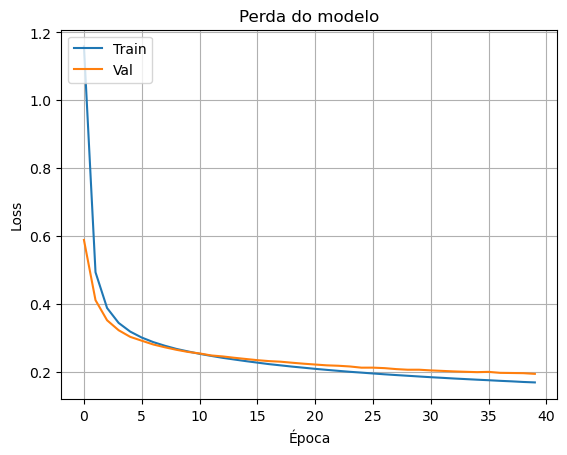

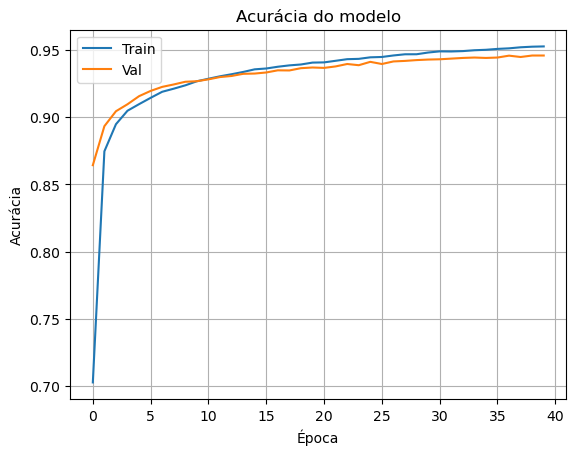

1563/1563 [==============================] - 1s 788us/step - loss: 0.1653 - accuracy: 0.9536
Treinamento: [0.16527731716632843, 0.9536200165748596]
313/313 [==============================] - 0s 776us/step - loss: 0.1934 - accuracy: 0.9457
Validação: [0.19343769550323486, 0.9456999897956848]
313/313 [==============================] - 0s 771us/step - loss: 0.1879 - accuracy: 0.9471
Teste: [0.18786022067070007, 0.9470999836921692]


In [ ]:
# Cria o modelo
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(28, 28)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(20, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

# Define o otimizador
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)

# Compila a rede neural
model.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define quantidade de epocas
epochs = 40

# Treina o modelo
history = model.fit(
    train_images,
    train_labels,
    epochs=epochs,
    validation_data=(val_images, val_labels)
)

# Plota a perda
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Perda do modelo')
plt.ylabel('Loss')
plt.xlabel('Epoca')
plt.legend(loc='upper left')
plt.grid()
plt.show()

# Plota a acuracia
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Acuracia do modelo')
plt.ylabel('Acuracia')
plt.xlabel('Epoca')
plt.legend(loc='upper left')
plt.grid()
plt.show()

# Avalia nos tres conjuntos
print('Treinamento:', model.evaluate(train_images, train_labels))
print('Validacao:', model.evaluate(val_images, val_labels))
print('Teste:', model.evaluate(test_images, test_labels))

### O que você conclui sobre o treinamento deste outro modelo? Podemos dizer que o modelo treinado tem um bom desempenho? Caso não, o que pode ser feito para melhorar este desempenho?

**Justifique suas respostas**

**Resposta**

Este modelo teve desempenho melhor que o anterior, pois a taxa de aprendizado menor deixou o treinamento mais estável. Mesmo assim, o modelo ainda é simples, com apenas uma camada escondida pequena. Para melhorar, pode-se aumentar um pouco a arquitetura, treinar por mais épocas ou testar uma taxa de aprendizado um pouco maior.

## Execute a célula de código abaixo e analise o código (mais especificamente a arquitetura da rede neural), as figuras geradas e os resultados de desempenho nos três conjuntos.

Epoch 1/100
1563/1563 [==============================] - 3s 1ms/step - loss: 0.6566 - accuracy: 0.8248 - val_loss: 0.2903 - val_accuracy: 0.9172
Epoch 2/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.2551 - accuracy: 0.9263 - val_loss: 0.2224 - val_accuracy: 0.9356
Epoch 3/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.1975 - accuracy: 0.9433 - val_loss: 0.1841 - val_accuracy: 0.9465
Epoch 4/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.1633 - accuracy: 0.9524 - val_loss: 0.1602 - val_accuracy: 0.9539
Epoch 5/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.1390 - accuracy: 0.9598 - val_loss: 0.1446 - val_accuracy: 0.9576
Epoch 6/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.1208 - accuracy: 0.9650 - val_loss: 0.1326 - val_accuracy: 0.9614
Epoch 7/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.1069 - accuracy: 0.9697 - val_loss: 0.1214 - val_ac

1563/1563 [==============================] - 2s 1ms/step - loss: 8.3911e-04 - accuracy: 0.9999 - val_loss: 0.1337 - val_accuracy: 0.9767
Epoch 58/100
1563/1563 [==============================] - 2s 1ms/step - loss: 9.3879e-04 - accuracy: 0.9999 - val_loss: 0.1578 - val_accuracy: 0.9730
Epoch 59/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.0024 - accuracy: 0.9994 - val_loss: 0.1341 - val_accuracy: 0.9768
Epoch 60/100
1563/1563 [==============================] - 2s 1ms/step - loss: 3.4581e-04 - accuracy: 1.0000 - val_loss: 0.1379 - val_accuracy: 0.9767
Epoch 61/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.0015 - accuracy: 0.9997 - val_loss: 0.1371 - val_accuracy: 0.9770
Epoch 62/100
1563/1563 [==============================] - 2s 1ms/step - loss: 4.6487e-04 - accuracy: 1.0000 - val_loss: 0.1374 - val_accuracy: 0.9773
Epoch 63/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.0026 - accuracy: 0.9993 - val_loss: 0.140

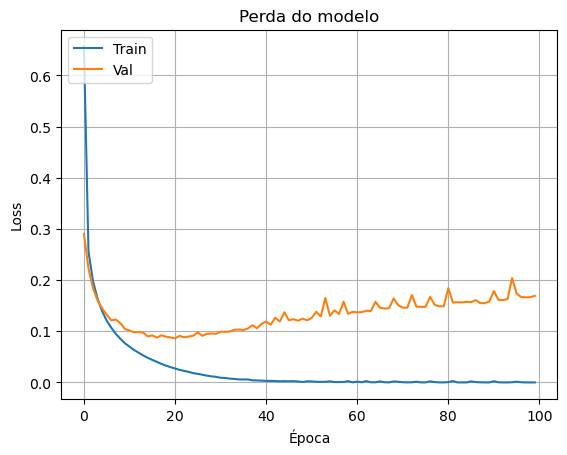

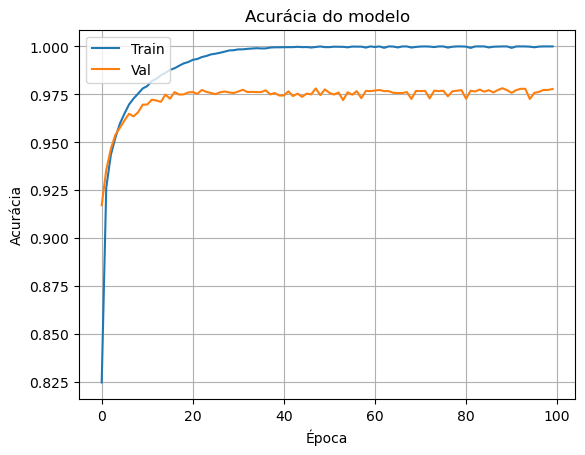

1563/1563 [==============================] - 1s 884us/step - loss: 3.7527e-05 - accuracy: 1.0000
Treinamento: [3.7527068343479186e-05, 1.0]
313/313 [==============================] - 0s 863us/step - loss: 0.1692 - accuracy: 0.9778
Validação: [0.16921097040176392, 0.9778000116348267]
313/313 [==============================] - 0s 870us/step - loss: 0.1521 - accuracy: 0.9781
Teste: [0.15212884545326233, 0.9781000018119812]


In [ ]:
# Cria o modelo
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(28, 28)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(32, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

# Define o otimizador
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)

# Compila a rede neural
model.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define quantidade de epocas
epochs = 100

# Treina o modelo
history = model.fit(
    train_images,
    train_labels,
    epochs=epochs,
    validation_data=(val_images, val_labels)
)

# Plota a perda
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Perda do modelo')
plt.ylabel('Loss')
plt.xlabel('Epoca')
plt.legend(loc='upper left')
plt.grid()
plt.show()

# Plota a acuracia
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Acuracia do modelo')
plt.ylabel('Acuracia')
plt.xlabel('Epoca')
plt.legend(loc='upper left')
plt.grid()
plt.show()

# Avalia nos tres conjuntos
print('Treinamento:', model.evaluate(train_images, train_labels))
print('Validacao:', model.evaluate(val_images, val_labels))
print('Teste:', model.evaluate(test_images, test_labels))

### O que você conclui sobre o treinamento deste outro modelo? Podemos dizer que o modelo treinado tem um bom desempenho? Caso não, o que pode ser feito para melhorar este desempenho?

**Justifique suas respostas**

**Resposta**

Este modelo apresentou o melhor comportamento entre os modelos testados. A rede maior conseguiu aprender padrões mais complexos das imagens e manteve resultados bons nos conjuntos de validação e teste. Como os resultados entre treino, validação e teste ficaram próximos, o desempenho pode ser considerado bom.

## Execute a célula de código abaixo e analise as figuras geradas e os resultados de desempenho nos três conjuntos.

Epoch 1/40
1563/1563 [==============================] - 2s 1ms/step - loss: 2.4532 - accuracy: 0.0635 - val_loss: 2.4485 - val_accuracy: 0.0649
Epoch 2/40
1563/1563 [==============================] - 2s 1ms/step - loss: 2.4480 - accuracy: 0.0642 - val_loss: 2.4433 - val_accuracy: 0.0655
Epoch 3/40
1563/1563 [==============================] - 2s 1ms/step - loss: 2.4429 - accuracy: 0.0648 - val_loss: 2.4381 - val_accuracy: 0.0667
Epoch 4/40
1563/1563 [==============================] - 2s 1ms/step - loss: 2.4378 - accuracy: 0.0656 - val_loss: 2.4330 - val_accuracy: 0.0670
Epoch 5/40
1563/1563 [==============================] - 2s 1ms/step - loss: 2.4329 - accuracy: 0.0660 - val_loss: 2.4280 - val_accuracy: 0.0679
Epoch 6/40
1563/1563 [==============================] - 2s 1ms/step - loss: 2.4280 - accuracy: 0.0671 - val_loss: 2.4231 - val_accuracy: 0.0685
Epoch 7/40
1563/1563 [==============================] - 2s 991us/step - loss: 2.4232 - accuracy: 0.0680 - val_loss: 2.4183 - val_accurac

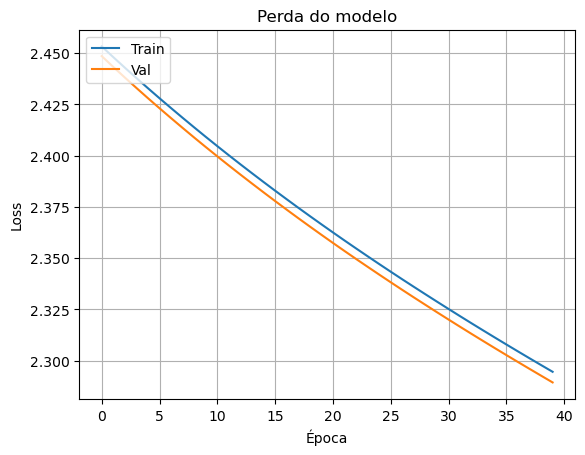

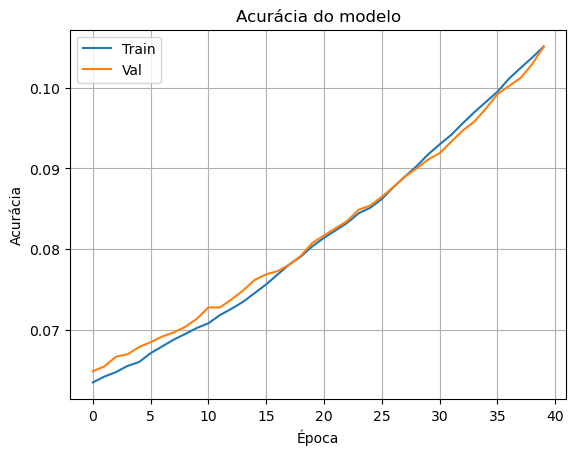

1563/1563 [==============================] - 1s 752us/step - loss: 2.2929 - accuracy: 0.1058
Treinamento: [2.292898178100586, 0.10577999800443649]
313/313 [==============================] - 0s 744us/step - loss: 2.2894 - accuracy: 0.1051
Validação: [2.289364814758301, 0.10509999841451645]
313/313 [==============================] - 0s 768us/step - loss: 2.3041 - accuracy: 0.0945
Teste: [2.3041093349456787, 0.09449999779462814]


In [ ]:
# Cria o modelo
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(28, 28)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(20, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

# Define o otimizador
opt = tf.keras.optimizers.Adam(learning_rate=0.0000001)

# Compila a rede neural
model.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define quantidade de epocas
epochs = 40

# Treina o modelo
history = model.fit(
    train_images,
    train_labels,
    epochs=epochs,
    validation_data=(val_images, val_labels)
)

# Plota a perda
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Perda do modelo')
plt.ylabel('Loss')
plt.xlabel('Epoca')
plt.legend(loc='upper left')
plt.grid()
plt.show()

# Plota a acuracia
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Acuracia do modelo')
plt.ylabel('Acuracia')
plt.xlabel('Epoca')
plt.legend(loc='upper left')
plt.grid()
plt.show()

# Avalia nos tres conjuntos
print('Treinamento:', model.evaluate(train_images, train_labels))
print('Validacao:', model.evaluate(val_images, val_labels))
print('Teste:', model.evaluate(test_images, test_labels))

### O que você conclui sobre o treinamento deste outro modelo? Podemos dizer que o modelo treinado tem um bom desempenho? Caso não, o que pode ser feito para melhorar este desempenho? Compare os resultados das figuras acima com os resultados obtidos com o treinamento do segundo modelo.

**Justifique suas respostas**

**Resposta**

Este modelo não teve bom desempenho. A taxa de aprendizado ficou muito pequena, então os pesos mudaram muito pouco a cada época e a rede quase não conseguiu aprender. Comparando com o segundo modelo, que usou taxa de aprendizado 0.0001, este treinamento foi bem mais lento e teve resultados piores.